# # Analise Exploratória de dados-EDA (PNS/Asma)

> **Objetivo:** oferecer uma **Análise Exploratória de Dados (EDA)** clara e acessível — com **estatística descritiva, gráficos, manipulação básica** e **análises bivariadas** — para que até pessoas com pouca familiaridade com programação entendam os resultados.

**Como usar**
- Rode as células na ordem, de cima para baixo (Menu: *Run* → *Run All*).
- Os gráficos são criados com **matplotlib** (sem estilos especiais), um por figura.
- O notebook tenta detectar automaticamente o **desfecho (target)** (ex.: `num_asma`). Se necessário, ajuste a variável `TARGET_CANDIDATES`.
- Para evitar dezenas de gráficos, você pode ajustar os limites (ex.: `N_NUM_PLOTS`, `N_CAT_PLOTS`).

## 1. Imports e configurações

In [1]:
# Bibliotecas
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Opções de exibição
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

# Parâmetros do notebook (ajuste conforme necessário)
N_NUM_PLOTS = 12       # nº máx. de gráficos univariados para variáveis numéricas
N_CAT_PLOTS = 10       # nº máx. de gráficos univariados para variáveis categóricas
N_BINS = 30            # nº de bins para histogramas
N_TOP_MISSING = 20     # top colunas com mais ausentes no gráfico
N_NUM_BIV_PLOTS = 8    # nº máx. de gráficos bivariados numéricos x target
N_CAT_BIV_PLOTS = 8    # nº máx. de gráficos bivariados categóricos x target
HEATMAP_MAX = 25       # nº máx. de colunas no heatmap de correlação

# Candidatos de nome para o desfecho (target)
TARGET_CANDIDATES = ["num_asma", "asma", "target", "desfecho", "y", "label"]

# Aumenta tamanho padrão das figuras para facilitar leitura
plt.rcParams["figure.figsize"] = (6, 4)

## 2. Carregamento dos dados

In [2]:
# 2. Carregamento dos dados
import pandas as pd

DATA_PATH = "dados_preprocessados.csv"  # mesmo diretório do notebook

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (90846, 46)


,num_asma,catl_sexo,catl_cor_raca,catl_doenca_cronica,num_idade,catl_tipo_de_area,catl_tipo_de_domicilio,cath_material_parede,cath_fonte_de_agua,cath_destino_do_esgoto,catl_destino_do_lixo,catl_animais,catl_cachoros,catl_gatos,ord_saude,catl_atividade,num_consultas,catl_homeopatia,catl_internacao,cath_trabalho,catl_quimicos,catl_ruidos,catl_sol,catl_material_biologico,catl_plano_saude,catl_medicamentos,catl_plantas_medicinais,catl_deixar_atividades,cath_principal_motivo,cath_local_atendimento,catl_servico_saude,catl_recebeu_atendimento,catl_lixo,catl_poeira_mineral,cath_estado_agua,ord_agente_saude,ord_nivel_plano,catl_plano_consultas,catl_plano_exames,catl_plano_internacoes,ord_remedio_semana,catl_cigarro,catl_domicilio_cadastrado,ord_remedio_sus,ord_farmacia_popular,catl_pagou_remedio
0,0.0,Feminino,Branca,Sim,55.0,Capital,Casa,Alvenaria revestida,Rede geral,Fossa rudimentar,Coletado,Sim,2.0,0.0,Regular,NaN,2.0,NaN,Não,Autônomo,Não,Não,Não,Não,Não,NaN,NaN,Não,NaN,Unidade básica de saúde,Não,NaN,Não,Não,Filtrada,Uma vez,NaN,NaN,NaN,NaN,NaN,NaN,Sim,NaN,NaN,NaN
1,0.0,Feminino,Parda,Não,19.0,Capital,Casa,Alvenaria revestida,Poço raso,Fossa rudimentar,Coletado,Sim,0.0,1.0,Bom,NaN,1.0,NaN,Não,Autônomo,Não,Sim,Não,Não,Não,NaN,NaN,Não,NaN,NaN,Não,NaN,Não,Não,Mineral industrializada,Nunca recebeu,NaN,NaN,NaN,NaN,NaN,Sim,Sim,NaN,NaN,NaN
2,0.0,Feminino,Preta,Não,45.0,Capital,Casa,Alvenaria revestida,Rede geral,Fossa rudimentar,Coletado,Sim,1.0,1.0,Bom,NaN,NaN,NaN,Não,Setor privado,Sim,Não,Não,Não,Não,NaN,NaN,Não,NaN,NaN,Não,NaN,Sim,Não,Filtrada,Uma vez,NaN,NaN,NaN,NaN,NaN,Não,Sim,NaN,NaN,NaN
3,0.0,Feminino,Preta,Não,58.0,Capital,Casa,Alvenaria revestida,Rede geral,Fossa rudimentar,Coletado,Sim,1.0,0.0,Regular,NaN,NaN,NaN,Não,Setor privado,Não,Não,Não,Não,Não,NaN,NaN,Não,NaN,NaN,Não,NaN,Não,Não,Sem tratamento no domicílio,Nunca recebeu,NaN,NaN,NaN,NaN,NaN,Não,Sim,NaN,NaN,NaN
4,0.0,Feminino,Parda,Não,28.0,Capital,Apartamento,Alvenaria revestida,Rede geral,Fossa rudimentar,Coletado,Não,NaN,NaN,Bom,NaN,2.0,NaN,Não,NaN,NaN,NaN,NaN,NaN,Não,NaN,NaN,Não,NaN,UPA/Pronto atendimento público,Não,NaN,NaN,NaN,Sem tratamento no domicílio,Nunca recebeu,NaN,NaN,NaN,NaN,NaN,NaN,Sim,NaN,NaN,NaN


### 3 Distribuição da Variável de Desfecho (`num_asma`)

A variável `num_asma` representa o diagnóstico de asma informado no banco de dados. 
Ela é o nosso **desfecho (target)** e possui dois valores possíveis:

- **0**: Pessoa **não tem asma**
- **1**: Pessoa **tem asma**

Abaixo, apresentamos um gráfico de pizza com a proporção de cada grupo. 
Esse tipo de visualização ajuda a entender o balanceamento da variável-alvo, o que é importante para o desenvolvimento de modelos de aprendizado de máquina. 
Um desbalanceamento muito grande pode exigir técnicas adicionais de balanceamento ou ajustes no modelo.


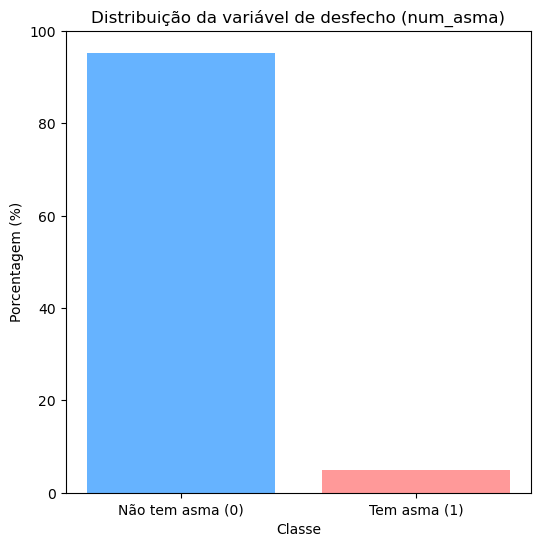

In [3]:
import matplotlib.pyplot as plt

# Contagem de cada classe
asma_counts = df["num_asma"].value_counts(normalize=True) * 100
labels = ['Não tem asma (0)', 'Tem asma (1)']
colors = ['#66b3ff', '#ff9999']

# Criar gráfico de barras
plt.figure(figsize=(6, 6))
plt.bar(labels, asma_counts, color=colors)
plt.title('Distribuição da variável de desfecho (num_asma)')
plt.ylabel('Porcentagem (%)')
plt.xlabel('Classe')
plt.ylim(0, 100)  # eixo Y vai até 100%
plt.show()


## 4. Separação de variáveis numéricas e categóricas

In [4]:
# Regras simples: números = numéricas; object/category/bool = categóricas
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Variáveis numéricas: {len(numeric_cols)}")
print(f"Variáveis categóricas: {len(categorical_cols)}")

# Mostra algumas
print("\nExemplos de numéricas:", numeric_cols[:10])
print("Exemplos de categóricas:", categorical_cols[:10])

Variáveis numéricas: 6
Variáveis categóricas: 40

Exemplos de numéricas: ['num_asma', 'num_idade', 'catl_cachoros', 'catl_gatos', 'catl_atividade', 'num_consultas']
Exemplos de categóricas: ['catl_sexo', 'catl_cor_raca', 'catl_doenca_cronica', 'catl_tipo_de_area', 'catl_tipo_de_domicilio', 'cath_material_parede', 'cath_fonte_de_agua', 'cath_destino_do_esgoto', 'catl_destino_do_lixo', 'catl_animais']


## 5. Estatística descritiva — Variáveis numéricas

In [5]:
if len(numeric_cols) > 0:
    desc_num = df[numeric_cols].describe().T
    desc_num = desc_num.rename(columns={
        "count": "n", "mean": "média", "std": "desvio", "min": "mín", "25%": "q1",
        "50%": "mediana", "75%": "q3", "max": "máx"
    })
    display(desc_num.round(3).head(30))
else:
    print("Não há variáveis numéricas.")

,n,média,desvio,mín,q1,mediana,q3,máx
num_asma,90846.0,0.049,0.216,0.0,0.0,0.0,0.0,1.0
num_idade,90846.0,46.360,17.479,16.0,32.0,45.0,60.0,86.0
catl_cachoros,53905.0,1.509,1.554,0.0,1.0,1.0,2.0,83.0
catl_gatos,53905.0,0.767,1.576,0.0,0.0,0.0,1.0,40.0
catl_atividade,8825.0,6.183,4.703,1.0,2.0,5.0,10.0,14.0
num_consultas,71548.0,3.644,3.390,1.0,1.0,3.0,4.0,20.0


### 6. Histogramas (amostra)

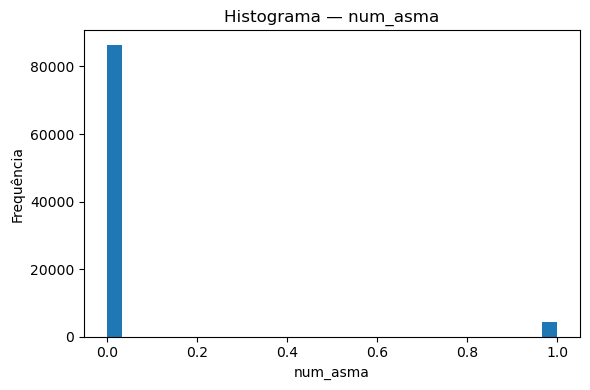

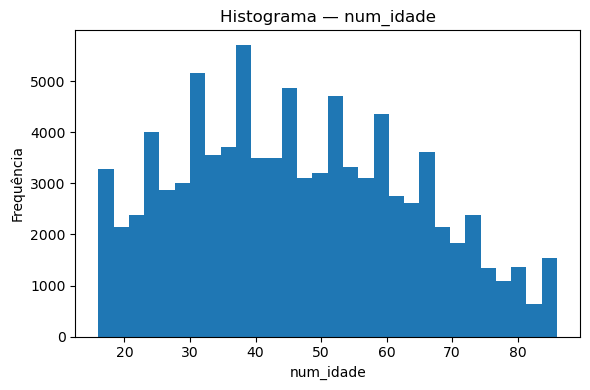

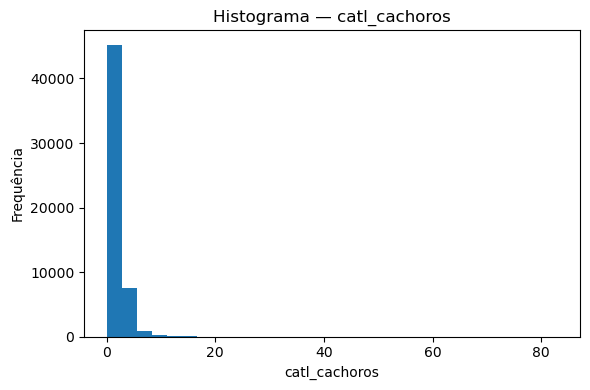

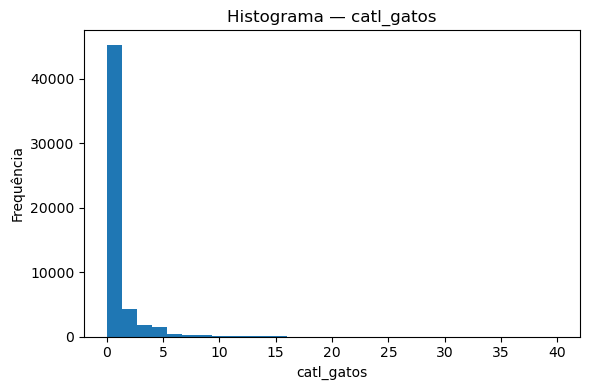

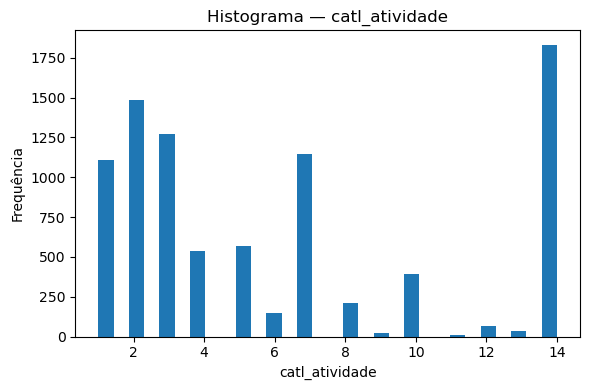

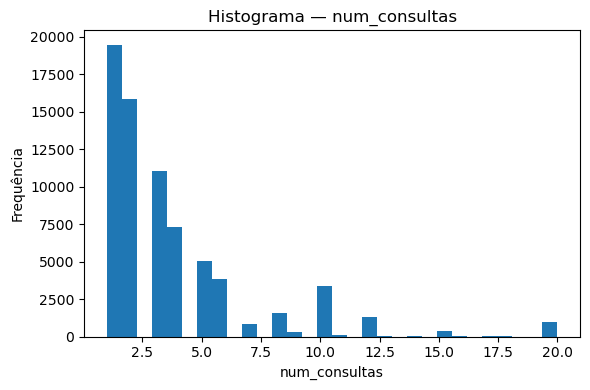

In [6]:
plot_cols = numeric_cols[:N_NUM_PLOTS]
for col in plot_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=N_BINS)
    plt.title(f"Histograma — {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

## 7. Identificação do desfecho (target)

In [7]:
target = None
lower_cols = {c.lower(): c for c in df.columns}
for cand in TARGET_CANDIDATES:
    if cand in lower_cols:
        target = lower_cols[cand]
        break

if target is not None:
    # Verifica se parece binário
    uniq = pd.Series(df[target].dropna().unique())
    print(f"Target detectado: {target}")
    print(f"Alguns valores únicos: {uniq[:10].tolist()}")
else:
    print("Target não detectado automaticamente. Ajuste a lista TARGET_CANDIDATES se necessário.")

Target detectado: num_asma
Alguns valores únicos: [0.0, 1.0]


## 8. Análises bivariadas — Numéricas × Target

,SMD_aprox,media_0,media_1,n_0,n_1
variavel,,,,,
num_consultas,0.271,3.594,4.510,67679,3869
num_idade,-0.139,46.480,44.048,86379,4467
catl_atividade,-0.058,6.206,5.935,8087,738
catl_gatos,-0.024,0.769,0.730,51182,2723
catl_cachoros,-0.002,1.510,1.506,51182,2723
num_asma,NaN,0.000,1.000,86379,4467


<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

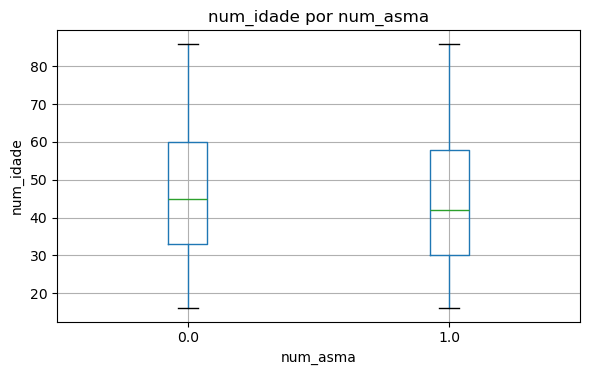

<Figure size 600x400 with 0 Axes>

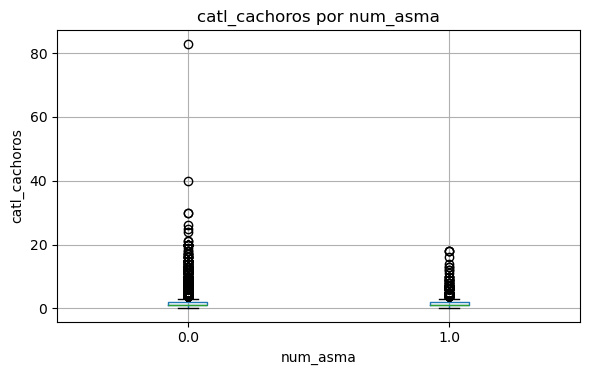

<Figure size 600x400 with 0 Axes>

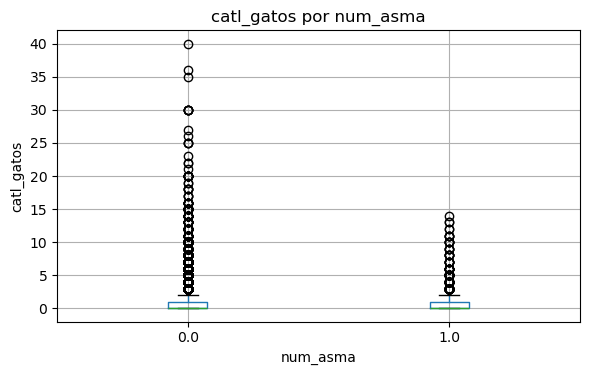

<Figure size 600x400 with 0 Axes>

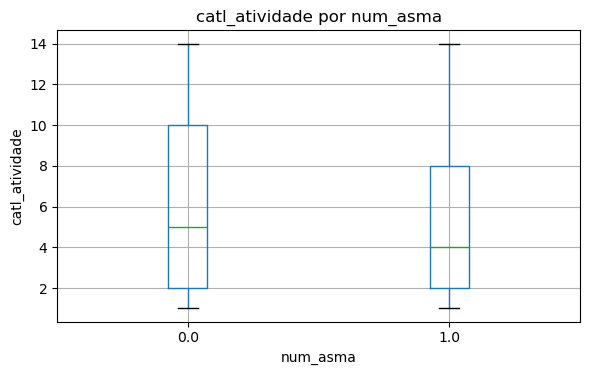

<Figure size 600x400 with 0 Axes>

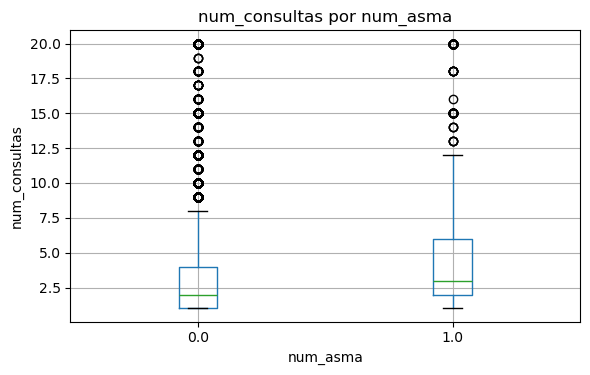

In [8]:
def standardized_mean_diff(x, g):
    # Diferença de médias padronizada (Cohen's d aproximado) para grupos 0/1
    groups = [x[g == 0].dropna(), x[g == 1].dropna()]
    if any(len(gi) == 0 for gi in groups):
        return np.nan
    m0, m1 = groups[0].mean(), groups[1].mean()
    s0, s1 = groups[0].std(ddof=1), groups[1].std(ddof=1)
    n0, n1 = len(groups[0]), len(groups[1])
    # Desvio combinado (pooled)
    sp = np.sqrt(((n0-1)*s0**2 + (n1-1)*s1**2) / (n0 + n1 - 2)) if (n0 + n1 - 2) > 0 else np.nan
    if sp == 0 or np.isnan(sp):
        return np.nan
    return (m1 - m0) / sp

if target is not None and target in df.columns and len(numeric_cols) > 0:
    # Resumo de diferenças por grupo (0/1 assumido)
    if set(pd.Series(df[target].dropna().unique()).astype(int).unique()).issubset({0,1}):
        rows = []
        for col in numeric_cols:
            try:
                g = df[target].astype(float)
                smd = standardized_mean_diff(df[col].astype(float), g)
                grp = df.groupby(target)[col].agg(["mean","median","std","count"])
                rows.append({
                    "variavel": col,
                    "SMD_aprox": smd,
                    "media_0": grp.loc[0, "mean"] if 0 in grp.index else np.nan,
                    "media_1": grp.loc[1, "mean"] if 1 in grp.index else np.nan,
                    "n_0": grp.loc[0, "count"] if 0 in grp.index else 0,
                    "n_1": grp.loc[1, "count"] if 1 in grp.index else 0
                })
            except Exception:
                pass
        biv_num = pd.DataFrame(rows).set_index("variavel").sort_values("SMD_aprox", key=lambda s: s.abs(), ascending=False)
        display(biv_num.round(3).head(20))

        # Boxplots por grupo (amostra)
        for col in numeric_cols[:N_NUM_BIV_PLOTS]:
            try:
                plt.figure()
                df[[col, target]].boxplot(by=target)
                plt.title(f"{col} por {target}")
                plt.suptitle("")
                plt.xlabel(target)
                plt.ylabel(col)
                plt.tight_layout()
                plt.show()
            except Exception:
                pass
    else:
        print(f"O target '{target}' não parece ser binário 0/1, então este bloco foi pulado.")
else:
    print("Sem target detectado ou não há variáveis numéricas.")

## 9. Análises bivariadas — Categóricas × Target

,prop_target_1
catl_sexo,
Feminino,0.058089
Masculino,0.039160


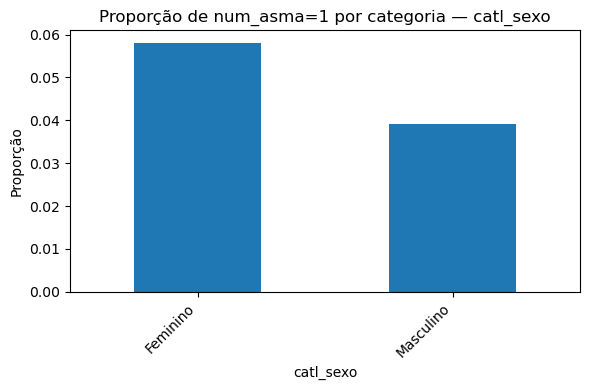

,prop_target_1
catl_cor_raca,
Branca,0.053663
Preta,0.051426
Parda,0.045723
Amarela,0.044118
Indigena,0.035088


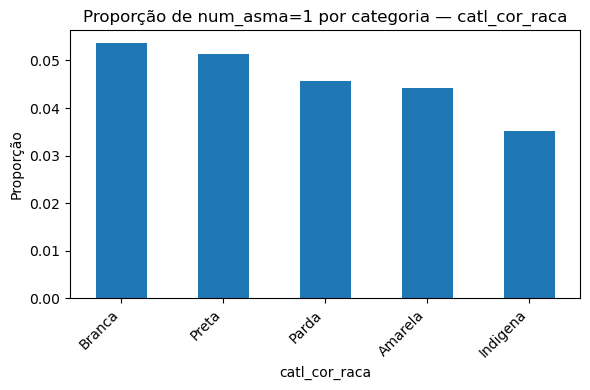

,prop_target_1
catl_doenca_cronica,
Sim,0.094143
Não,0.000000


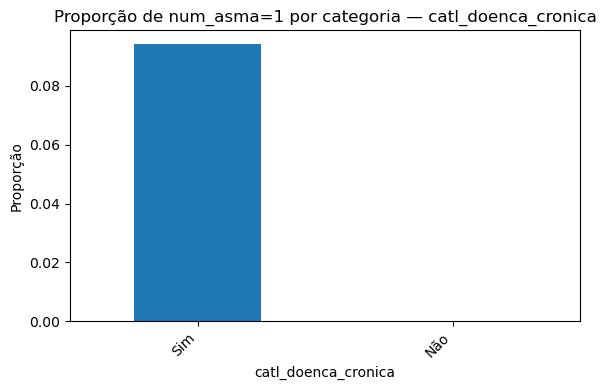

,prop_target_1
catl_tipo_de_area,
Capital,0.057728
Resto de RM,0.052759
Resto da UF,0.045226
RIDE,0.041651


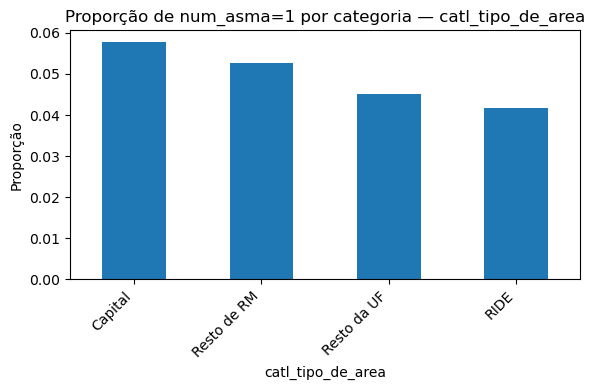

,prop_target_1
catl_tipo_de_domicilio,
Apartamento,0.068190
Cortiço,0.056452
Casa,0.046548


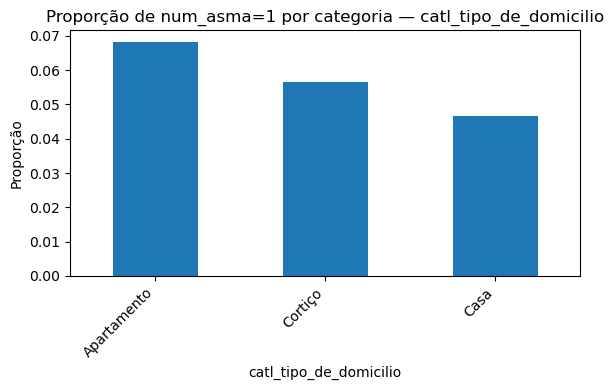

,prop_target_1
cath_material_parede,
Alvenaria revestida,0.050063
Alvenaria sem revestimento,0.046175
Aparelhada,0.046131
Outro,0.034483
Madeira aproveitada,0.032338
Taipa,0.027815


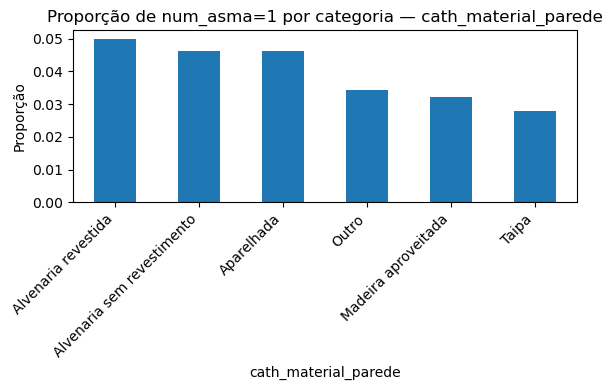

,prop_target_1
cath_fonte_de_agua,
Rede geral,0.051566
Poço profundo ou artesiano,0.044057
Fonte ou nascente,0.042117
Poço raso,0.041504
Água da chuva,0.032134
Outra,0.031500


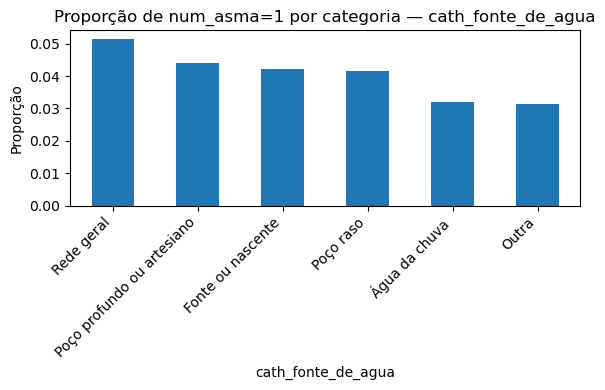

,prop_target_1
cath_destino_do_esgoto,
Rede geral,0.055803
Fossa séptica ligada à rede,0.051491
Fossa séptica não ligada à rede,0.046058
Outra,0.044674
Fossa rudimentar,0.041641
Rio/lago,0.040165
Vala,0.038145


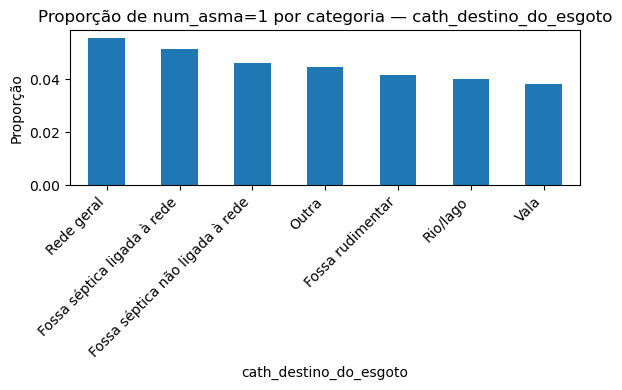

In [9]:
if target is not None and target in df.columns and len(categorical_cols) > 0:
    # Tabelas de proporção do target=1 por categoria (amostra)
    # Se target não for binário 0/1, mostramos proporções gerais
    is_binary = set(pd.Series(df[target].dropna().unique()).astype(int).unique()).issubset({0,1})
    for col in categorical_cols[:N_CAT_BIV_PLOTS]:
        try:
            if is_binary:
                tab = pd.crosstab(df[col], df[target], normalize="index")
                if 1 in tab.columns:
                    prop1 = tab[1].rename("prop_target_1")
                else:
                    # Se não tiver '1' no conjunto, cria coluna vazia
                    prop1 = pd.Series(0, index=tab.index, name="prop_target_1")
                display(prop1.sort_values(ascending=False).head(20).to_frame())

                # Gráfico de barras
                plt.figure()
                prop1.sort_values(ascending=False).head(15).plot(kind="bar")
                plt.title(f"Proporção de {target}=1 por categoria — {col}")
                plt.ylabel("Proporção")
                plt.xticks(rotation=45, ha="right")
                plt.tight_layout()
                plt.show()
            else:
                tab = pd.crosstab(df[col], df[target], normalize="index")
                display(tab.head(10))

                plt.figure()
                tab.head(10).plot(kind="bar", stacked=True)
                plt.title(f"Distribuição do {target} por categoria — {col}")
                plt.ylabel("Proporção")
                plt.xticks(rotation=45, ha="right")
                plt.tight_layout()
                plt.show()
        except Exception:
            pass
else:
    print("Sem target detectado ou não há variáveis categóricas.")

## 10. Correlações entre variáveis numéricas

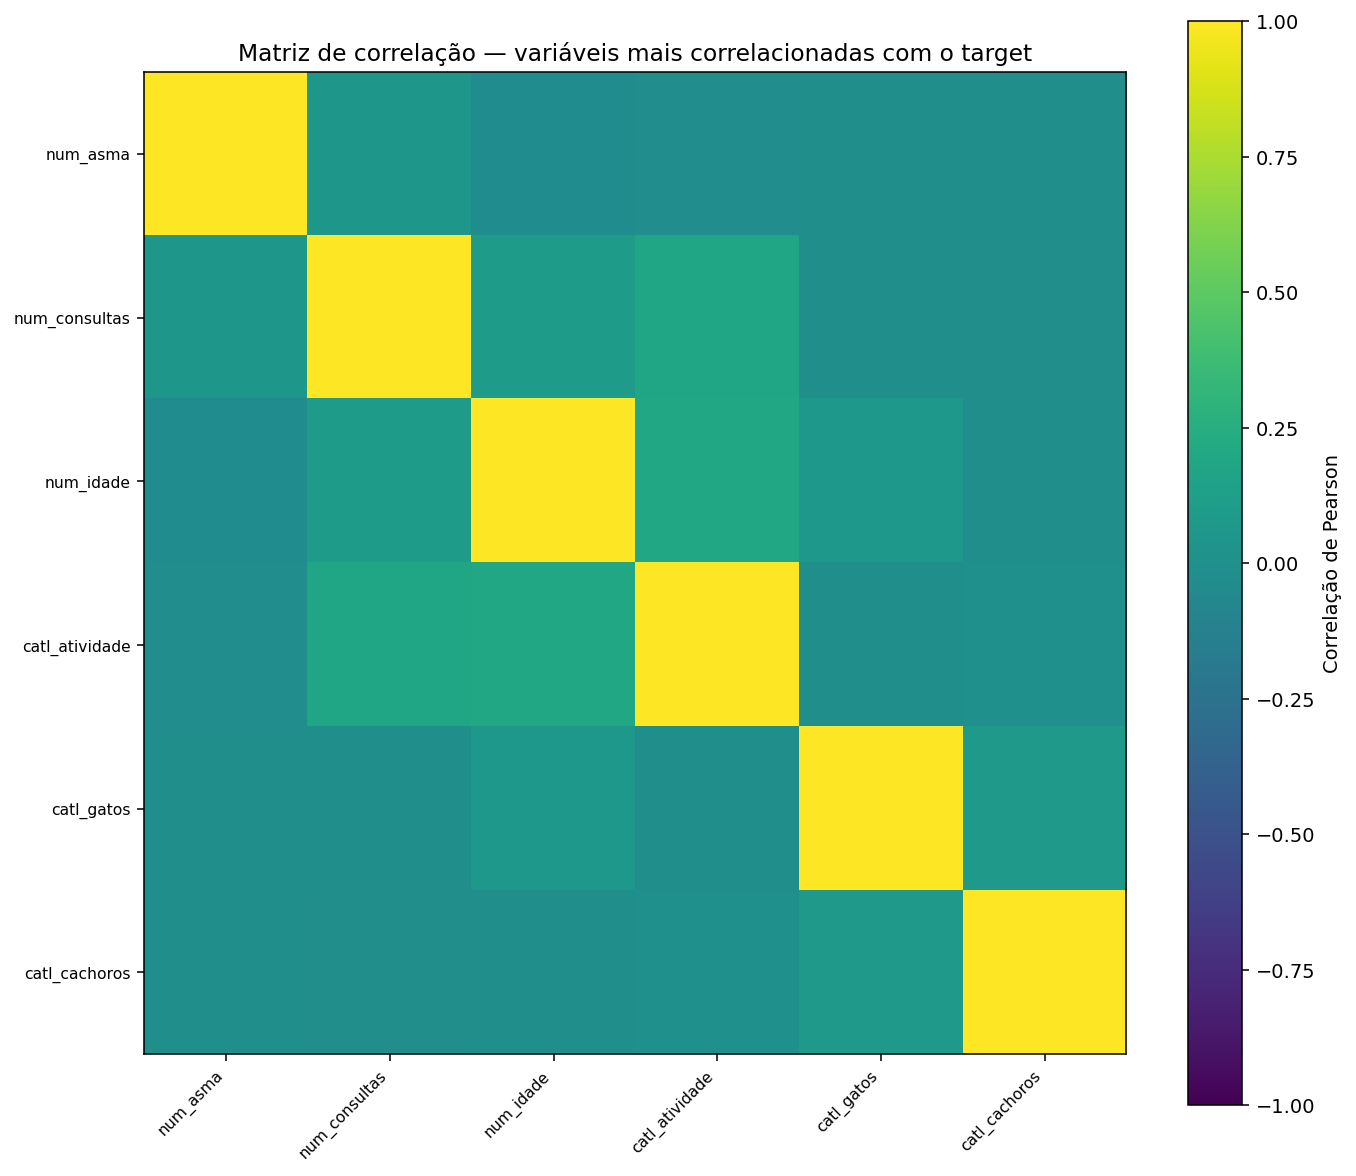

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET = "num_asma"  # troque se necessário
HEATMAP_MAX = 20     # nº máx. de variáveis no heatmap
ANNOTATE_THR = 0.40  # anotar valores nas células quando |corr| >= 0.40

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
if TARGET not in num_cols:
    raise ValueError(f"O target '{TARGET}' precisa ser numérico e estar no DataFrame.")

# 1) escolher as variáveis mais relevantes pelo |corr| com o target
corr_full = df[num_cols].corr(numeric_only=True)
rank = corr_full[TARGET].abs().sort_values(ascending=False)
subset = rank.head(HEATMAP_MAX).index.tolist()

# 2) matriz só desse subconjunto, ordenada pelo target
corr = corr_full.loc[subset, subset]

# 3) plot com labels legíveis
fig, ax = plt.subplots(figsize=(10,10), dpi=140)
im = ax.imshow(corr.values, vmin=-1, vmax=1, interpolation="nearest")

# barra de cores
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Correlação de Pearson")

# rótulos e formatação
ax.set_xticks(range(len(subset)))
ax.set_yticks(range(len(subset)))
ax.set_xticklabels(subset, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(subset, fontsize=8)
ax.set_title("Matriz de correlação — variáveis mais correlacionadas com o target")

# 4) (opcional) anotar valores nas células quando |corr| >= ANNOTATE_THR
for i in range(len(subset)):
    for j in range(len(subset)):
        val = corr.values[i, j]
        if i != j and abs(val) >= ANNOTATE_THR:
            ax.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.show()


## 11. Checklist simples de qualidade dos dados

In [11]:
# Linhas duplicadas
dup_rows = df.duplicated().sum()
print(f"Linhas duplicadas: {dup_rows}")

# Colunas constantes ou quase-constantes
const_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
low_variance_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 2]

print(f"Colunas constantes: {len(const_cols)}")
print(f"Colunas com variância muito baixa (<=2 valores únicos): {len(low_variance_cols)}")

if const_cols:
    print("Exemplos de colunas constantes:", const_cols[:10])
if low_variance_cols:
    print("Exemplos de baixa variância:", low_variance_cols[:10])

Linhas duplicadas: 30
Colunas constantes: 0
Colunas com variância muito baixa (<=2 valores únicos): 23
Exemplos de baixa variância: ['num_asma', 'catl_sexo', 'catl_doenca_cronica', 'catl_animais', 'catl_homeopatia', 'catl_internacao', 'catl_quimicos', 'catl_ruidos', 'catl_sol', 'catl_material_biologico']


### 12-Análise de Correlação com o Desfecho (`num_asma`)

A correlação mede a força e a direção da relação entre duas variáveis numéricas. 
Aqui, buscamos identificar quais variáveis possuem maior relação linear com o desfecho `num_asma`, que indica se a pessoa tem ou não diagnóstico de asma.

A seguir, apresentamos as **20 variáveis numéricas com maior correlação absoluta com o desfecho**, ordenadas do mais para o menos correlacionado. 
Essa análise ajuda a entender quais variáveis podem ser mais relevantes para a construção de modelos preditivos.

> 🔍 **Importante:** A correlação não implica causalidade. Mesmo que uma variável tenha forte correlação com o desfecho, isso não significa que ela causa o problema — apenas que existe uma associação estatística.


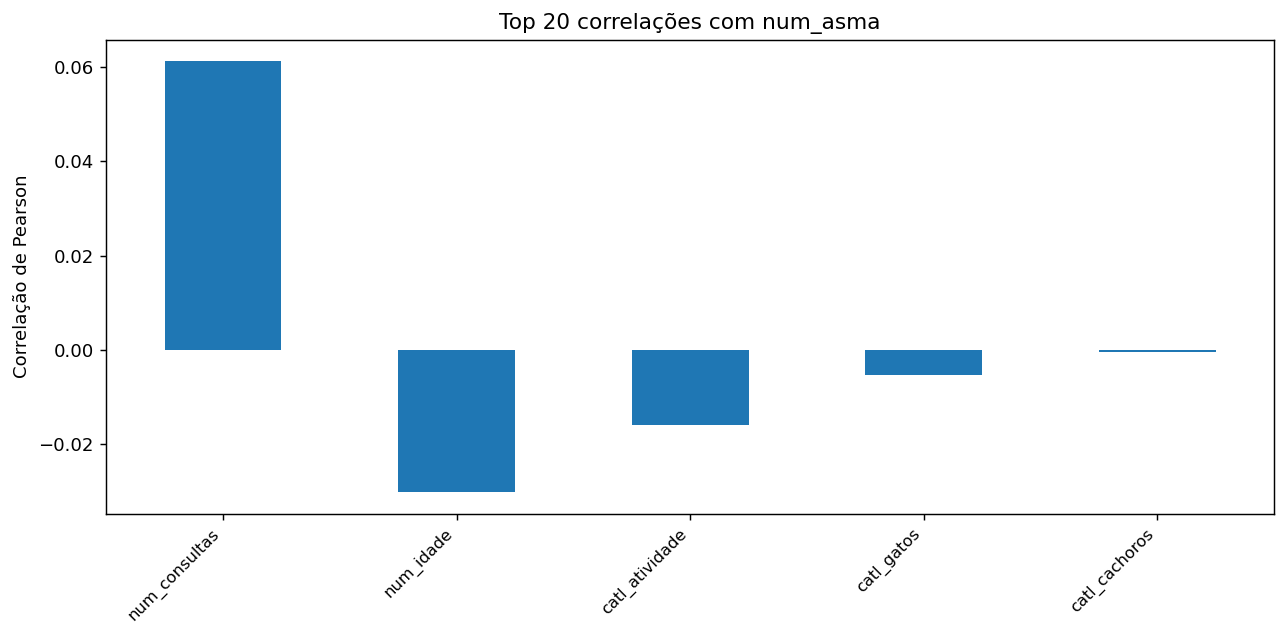

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET = "num_asma"

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
if TARGET not in num_cols:
    raise ValueError(f"O target '{TARGET}' precisa ser numérico e estar no DataFrame.")

corr_t = df[num_cols].corr(numeric_only=True)[TARGET].drop(TARGET)
corr_t = corr_t.reindex(corr_t.abs().sort_values(ascending=False).index)

top_k = 20  # quantas variáveis mostrar
plt.figure(figsize=(10,5), dpi=130)
corr_t.head(top_k).plot(kind="bar")
plt.title(f"Top {top_k} correlações com {TARGET}")
plt.ylabel("Correlação de Pearson")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()
